#📌 Extracción

In [2]:
pip install pandas

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.7 MB 13.4 MB/s eta 0:00:01
   ----------------- ---------------------- 4.2/9.7 MB 12.6 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.7 MB 15.8 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 15.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   --------- ------------------------------ 2.9/12.3 MB 14.3 MB/s eta 0:00:01
   -------------------- ------------------- 6.3/12.3 MB 14.5 MB/s eta 0:00:01
   ------------------------------ --------- 9.4/12.3 MB 14.7 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 14.3 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
pip install matplotlib seaborn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.1 MB 15.3 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 15.7 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 14.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 14.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.3 MB 10.4 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 9.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ----------- ---------------------------- 2.1/7.0 MB 10.5 MB/s eta 0:00:01
   ------------------------- -------------- 4.5/7.0 MB 10.7 MB/s eta 0:00:01
   -------------------------------------- - 6.8/7.0 MB 10.8 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 10.5 MB/s eta 0:00:00

   --------------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import json

# Ruta del archivo 
path = "TelecomX_Data.json"

# Cargamos el archivo JSON
with open(path, 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.json_normalize(data)

#🔧 Transformación

In [8]:
# Información general de los tipos de datos y valores nulos
df.info()

# Ver las primeras 5 filas para contrastar con el diccionario
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   str    
 1   Churn                      7267 non-null   str    
 2   customer.gender            7267 non-null   str    
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   str    
 5   customer.Dependents        7267 non-null   str    
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   str    
 8   phone.MultipleLines        7267 non-null   str    
 9   internet.InternetService   7267 non-null   str    
 10  internet.OnlineSecurity    7267 non-null   str    
 11  internet.OnlineBackup      7267 non-null   str    
 12  internet.DeviceProtection  7267 non-null   str    
 13  internet.TechSupport       7267 non-null   str    
 14  int

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [18]:
# 1. Corrección de Formato: Convertir Cargos Totales a numérico
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# 2. Identificar Valores Ausentes
df = df.replace('', np.nan)
nulos = df.isnull().sum()

print(" Valores nulos o vacíos detectados:")
print(nulos[nulos > 0])

# 3. Comprobar Duplicados
duplicados = df.duplicated(subset=['customerID']).sum()
print(f"\n Registros con customerID duplicado: {duplicados}")

# 4. Inconsistencias en Categorías Clave
print("\n Categorías en Churn:", df['Churn'].unique())
print(" Categorías en Internet Service:", df['internet.InternetService'].unique())

# 5. Inconsistencia Lógica: Clientes con cargos pero sin antigüedad
logica_fallida = df[(df['customer.tenure'] == 0) & (df['account.Charges.Total'] > 0)]
print(f"\n Casos de antigüedad 0 con cargos registrados: {len(logica_fallida)}")

 Valores nulos o vacíos detectados:
Churn                    224
account.Charges.Total     11
dtype: int64

 Registros con customerID duplicado: 0

 Categorías en Churn: <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
 Categorías en Internet Service: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

 Casos de antigüedad 0 con cargos registrados: 0


In [19]:
# 1. Copia de seguridad del DataFrame
df_final = df.copy()

# 2. Manejo de 'Churn' 
df_final = df_final.dropna(subset=['Churn'])

# 3. Manejo de 'account.Charges.Total'
df_final['account.Charges.Total'] = df_final['account.Charges.Total'].fillna(0)

# 4. Estandarización de textos 
df_final = df_final.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# --- VERIFICACIÓN FINAL ---
print(f" Limpieza completada.")
print(f" Registros originales: {len(df)}")
print(f" Registros actuales: {len(df_final)}")
print(f" Nulos restantes: {df_final.isnull().sum().sum()}")

 Limpieza completada.
 Registros originales: 7267
 Registros actuales: 7043
 Nulos restantes: 0


#📊 Carga y análisis

In [20]:
# 1. Estadísticas para variables numéricas 
desc_num = df_final.describe().T
print(" Métricas Descriptivas (Numéricas):")
display(desc_num)

# 2. Análisis de la Variable "Churn"
churn_counts = df_final['Churn'].value_counts()
churn_percentage = df_final['Churn'].value_counts(normalize=True) * 100

print("\n Distribución de Evasión (Churn):")
summary_churn = pd.DataFrame({
    'Cantidad': churn_counts,
    'Porcentaje (%)': churn_percentage
})
display(summary_churn)

# 3. Mediana vs Media 
print(f"\n Mediana de Cargos Mensuales: {df_final['account.Charges.Monthly'].median():.2f}")
print(f" Media de Cargos Mensuales: {df_final['account.Charges.Monthly'].mean():.2f}")

 Métricas Descriptivas (Numéricas):


,count,mean,std,min,25%,50%,75%,max
customer.SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
customer.tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
account.Charges.Monthly,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
account.Charges.Total,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80



 Distribución de Evasión (Churn):


,Cantidad,Porcentaje (%)
Churn,,
No,5174,73.463013
Yes,1869,26.536987



 Mediana de Cargos Mensuales: 70.35
 Media de Cargos Mensuales: 64.76


In [21]:
# ¿Cuánto pagan en promedio los que se van vs los que se quedan?
print("\n Promedio de cargos por estado de Churn:")
print(df_final.groupby('Churn')['account.Charges.Monthly'].mean())


 Promedio de cargos por estado de Churn:
Churn
No     61.265124
Yes    74.441332
Name: account.Charges.Monthly, dtype: float64


C:\Users\neril\AppData\Local\Temp\ipykernel_15140\1545471872.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df_final, palette='viridis')


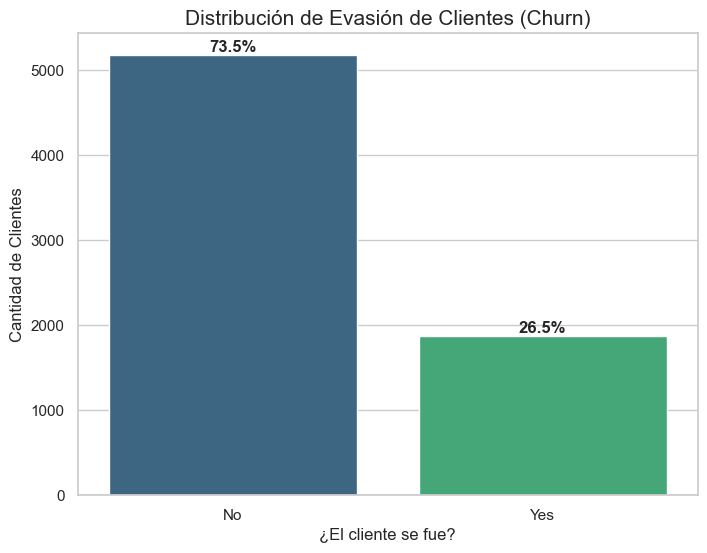

In [24]:
# Estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# 1. Gráfico de barras para la distribución de Churn
ax = sns.countplot(x='Churn', data=df_final, palette='viridis')

# Añadir títulos y etiquetas
plt.title('Distribución de Evasión de Clientes (Churn)', fontsize=15)
plt.xlabel('¿El cliente se fue?', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

# Añadir etiquetas de porcentaje sobre las barras
total = len(df_final)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

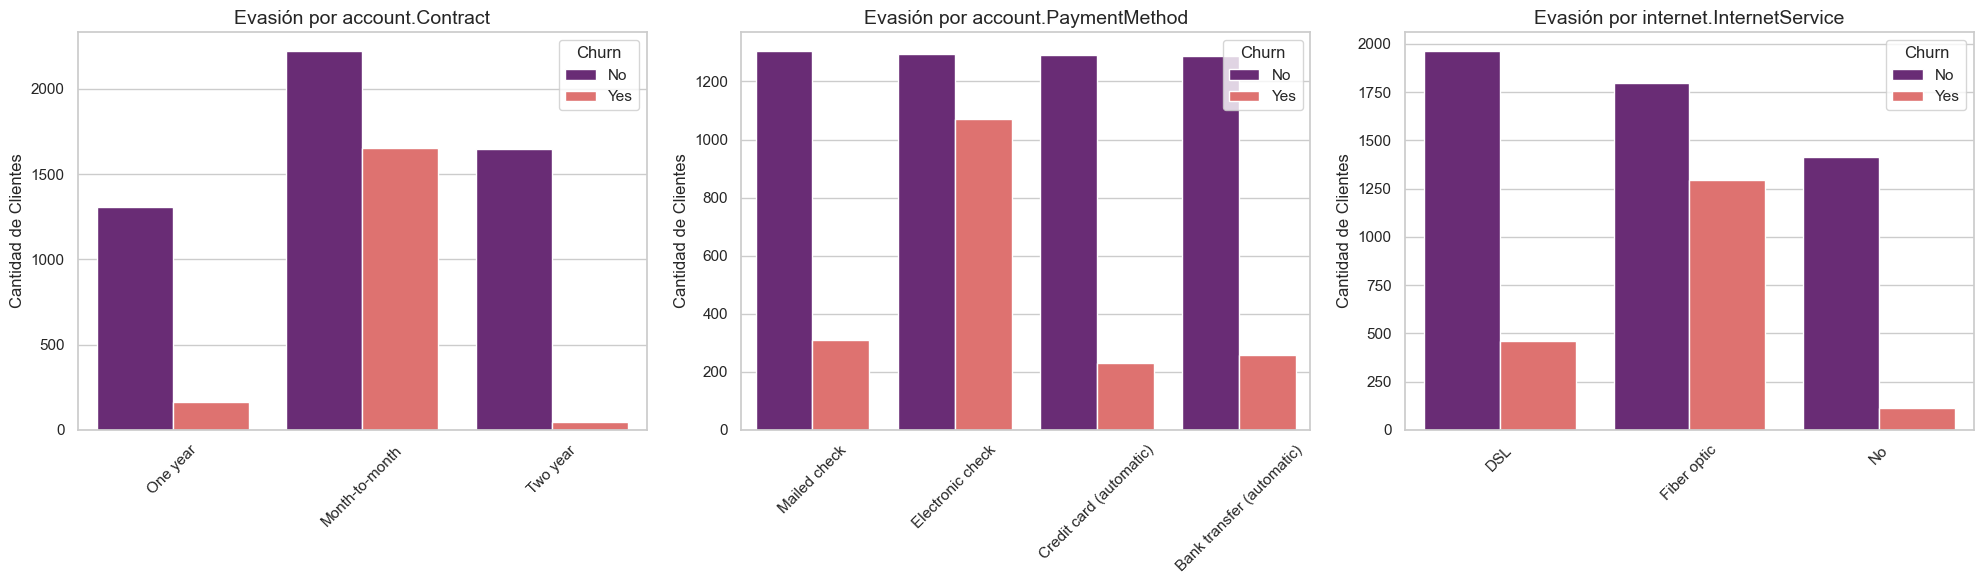

In [25]:
# Variables a analizar
cols_to_plot = ['account.Contract', 'account.PaymentMethod', 'internet.InternetService']

# 3 gráficos en una fila
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(cols_to_plot):
    # Creamos un gráfico de barras agrupado por Churn
    sns.countplot(x=col, hue='Churn', data=df_final, ax=axes[i], palette='magma')
    
    axes[i].set_title(f'Evasión por {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Cantidad de Clientes')
    axes[i].tick_params(axis='x', rotation=45) 

plt.tight_layout()
plt.show()

C:\Users\neril\AppData\Local\Temp\ipykernel_15140\1803601607.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df_final, ax=axes[i], palette='magma')
C:\Users\neril\AppData\Local\Temp\ipykernel_15140\1803601607.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df_final, ax=axes[i], palette='magma')
C:\Users\neril\AppData\Local\Temp\ipykernel_15140\1803601607.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df_final, ax=axes[i], palette='magma')


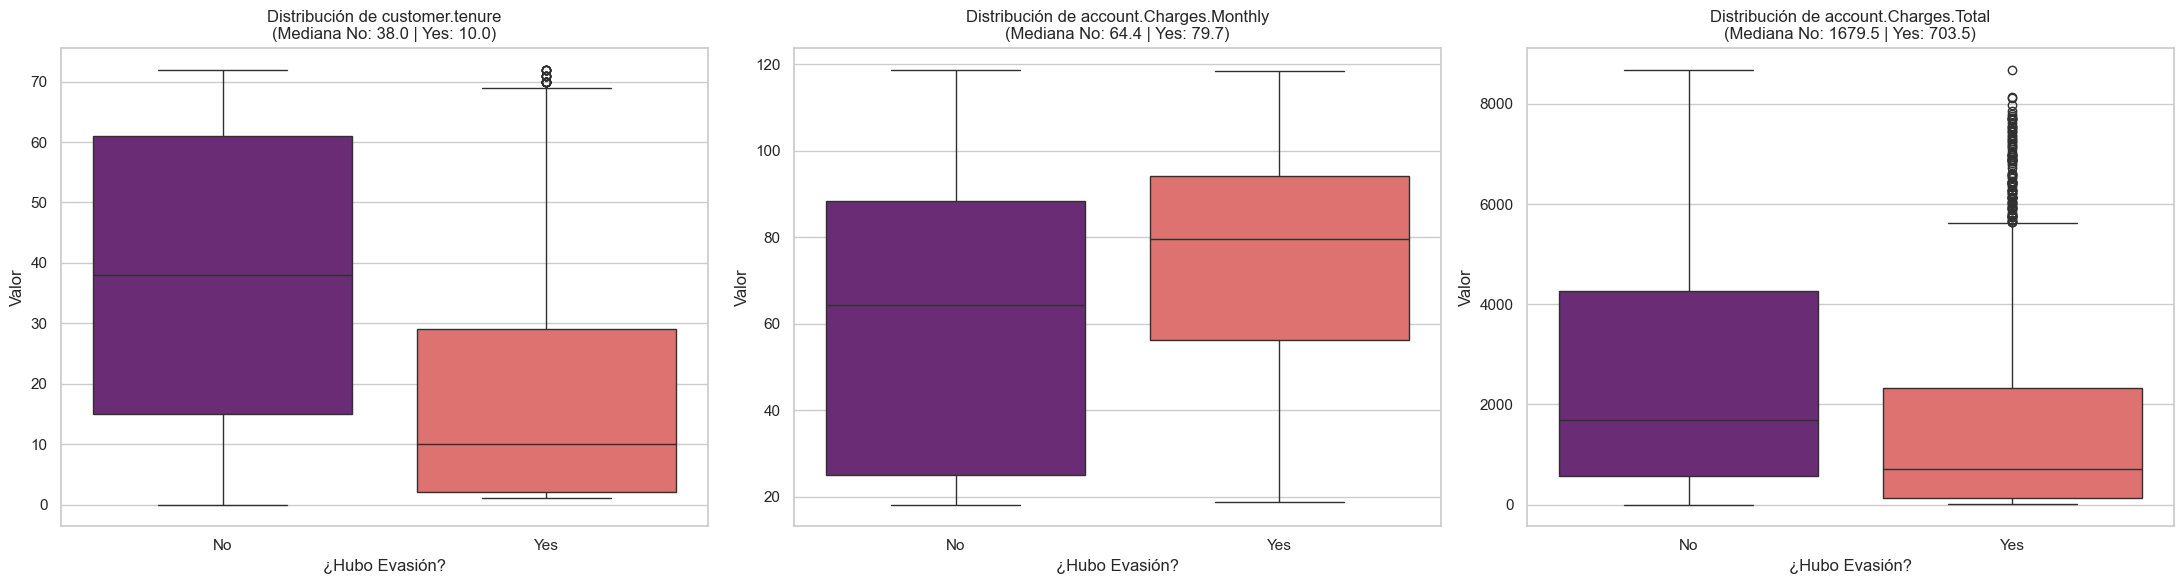

In [26]:
# Definimos las columnas 
num_cols = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']

# Grafiucos
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 6))

for i, col in enumerate(num_cols):
    # Medianas y dispersión
    sns.boxplot(x='Churn', y=col, data=df_final, ax=axes[i], palette='magma')
    
    median_stay = df_final[df_final['Churn'] == 'No'][col].median()
    median_churn = df_final[df_final['Churn'] == 'Yes'][col].median()
    
    axes[i].set_title(f'Distribución de {col}\n(Mediana No: {median_stay:.1f} | Yes: {median_churn:.1f})', fontsize=12)
    axes[i].set_xlabel('¿Hubo Evasión?')
    axes[i].set_ylabel('Valor')

plt.tight_layout()
plt.show()

#📄Informe final

# Análisis de Evasión: Telecom X

## 1. 🔹 Introducción
El objetivo de este proyecto fue analizar el fenómeno de **Churn (evasión de clientes)** en Telecom X. La empresa presentaba una pérdida constante de usuarios, y este análisis buscó identificar los factores críticos (demográficos, de servicio y financieros) que influyen en la decisión de un cliente de abandonar la compañía, con el fin de proponer estrategias de retención basadas en datos.

## 2. 🔹 Limpieza y Tratamiento de Datos
Para garantizar la confiabilidad de los hallazgos, se realizó un riguroso proceso de preparación:

* **Extracción:** Los datos se importaron desde una API en formato JSON y se transformaron a un DataFrame de Pandas mediante `json_normalize`.
* **Corrección de Tipos:** Se identificó que la columna `account.Charges.Total` era interpretada como texto; se convirtió a formato numérico.
* **Manejo de Nulos:** Se eliminaron 224 registros que no tenían información sobre la evasión (`Churn`), ya que representan el objetivo del análisis. Los nulos en cargos totales se completaron con $0$ (clientes nuevos).
* **Consistencia:** Se eliminaron espacios en blanco y se estandarizaron las categorías.
* **Resultado:** El dataset final cuenta con **7,043 registros limpios**.

## 3. 🔹 Análisis Exploratorio de Datos (EDA)
A través de las visualizaciones, identificamos los pilares de la evasión:

### A. Magnitud del Problema
La tasa de evasión es del **26.5%**. Esto significa que 1 de cada 4 clientes abandona la empresa, una cifra alarmante que requiere intervención inmediata.
### B. Perfil del Cliente Evasivo (Categorías)
* **Contrato:** Los clientes con contrato **"Month-to-month"** (mes a mes) son los más propensos a irse. Los contratos a largo plazo (1 o 2 años) casi no presentan fugas.
* **Método de Pago:** Existe una relación directa entre el **"Electronic Check"** (cheque electrónico) y la evasión.
* **Servicio:** Los usuarios de **Fibra Óptica** tienen una tasa de abandono superior a los de DSL, posiblemente debido a una relación costo-beneficio percibida como desfavorable.
### C. Factores Numéricos
* **Antigüedad (Tenure):** La mediana de antigüedad de los clientes que se van es de solo **10 meses**, comparado con los **38 meses** de los que permanecen.
* **Cargos Mensuales:** El cliente que se va paga significativamente más (Mediana: **$79.7$**) que el que se queda (Mediana: **$64.4$**).

## 4. 🔹 Conclusiones e Insights
1. **El "Trigger" es el Precio:** La evasión está impulsada por cargos mensuales altos. El cliente es sensible al precio cuando la factura supera los **$70 - $80**.
2. **La Vulnerabilidad es Temprana:** El primer año de servicio es el "valle de la muerte". Si un cliente supera los 12-18 meses, la probabilidad de que se quede aumenta drásticamente.
3. **Fragilidad de los Contratos Cortos:** El modelo "mes a mes" ofrece flexibilidad al cliente, pero no genera compromiso (lealtad) con la marca.

## 5. 🔹 Recomendaciones Estratégicas
* **Plan de Fidelización en el Primer Año:** Ofrecer descuentos progresivos o beneficios de lealtad específicamente entre el mes 1 y el 12.
* **Incentivo al Cambio de Contrato:** Crear campañas para migrar a clientes "mes a mes" hacia contratos anuales mediante una reducción en la tarifa mensual.
* **Revisión de la Oferta de Fibra Óptica:** Analizar la calidad del servicio o el precio de la fibra, ya que es el segmento con mayor rotación a pesar de ser un servicio "Premium".
* **Automatización de Pagos:** Promover el cambio de cheque electrónico a métodos automáticos (tarjeta o transferencia) ofreciendo un pequeño bono de descuento único.
